In [1]:
import pandas as pd


In [2]:
eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])
eq['Time'] = pd.to_datetime(eq['Time'], errors="coerce")
eq['Time'] = pd.to_datetime(eq['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')
eq['Time'] = pd.to_datetime(eq['Time'])


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_15960\1022411766.py:1: SyntaxWarning: invalid escape sequence '\P'
  eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])


In [3]:
eq

,Time,lat,long,depth,mag
0,2005-01-01 01:42:24,7.293,93.919,30.0,5.0
1,2005-01-01 01:43:40,7.034,92.462,35.5,5.2
2,2005-01-01 01:55:28,2.910,95.623,24.5,5.7
3,2005-01-01 04:03:10,5.465,94.398,36.0,5.7
4,2005-01-01 06:25:44,5.099,92.304,11.7,6.7
...,...,...,...,...,...
12437,2010-12-30 19:56:36,50.380,153.964,190.1,5.0
12438,2010-12-30 21:22:30,-19.984,168.353,20.2,5.0
12439,2010-12-30 23:47:03,-31.830,-178.135,35.0,5.0
12440,2010-12-31 04:11:03,-19.209,167.902,10.0,5.1


In [4]:
df=eq

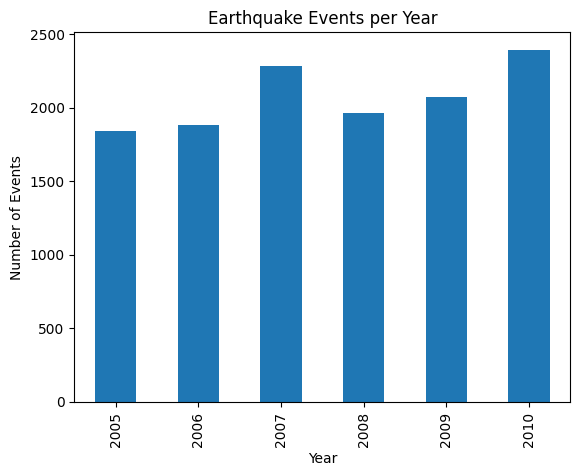

In [5]:
# Create a histogram of earthquake counts per year from the provided data

import pandas as pd
import matplotlib.pyplot as plt

# df = pd.DataFrame(data, columns=["Time", "lat", "long", "depth", "mag"])

# Convert Time to datetime and extract year
df["Time"] = pd.to_datetime(df["Time"])
df["Year"] = df["Time"].dt.year

# Count events per year
counts = df["Year"].value_counts().sort_index()

# Plot histogram (bar chart for counts per year)
plt.figure()
counts.plot(kind='bar')

plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("Earthquake Events per Year")

plt.show()

## Magnitude based Distribution

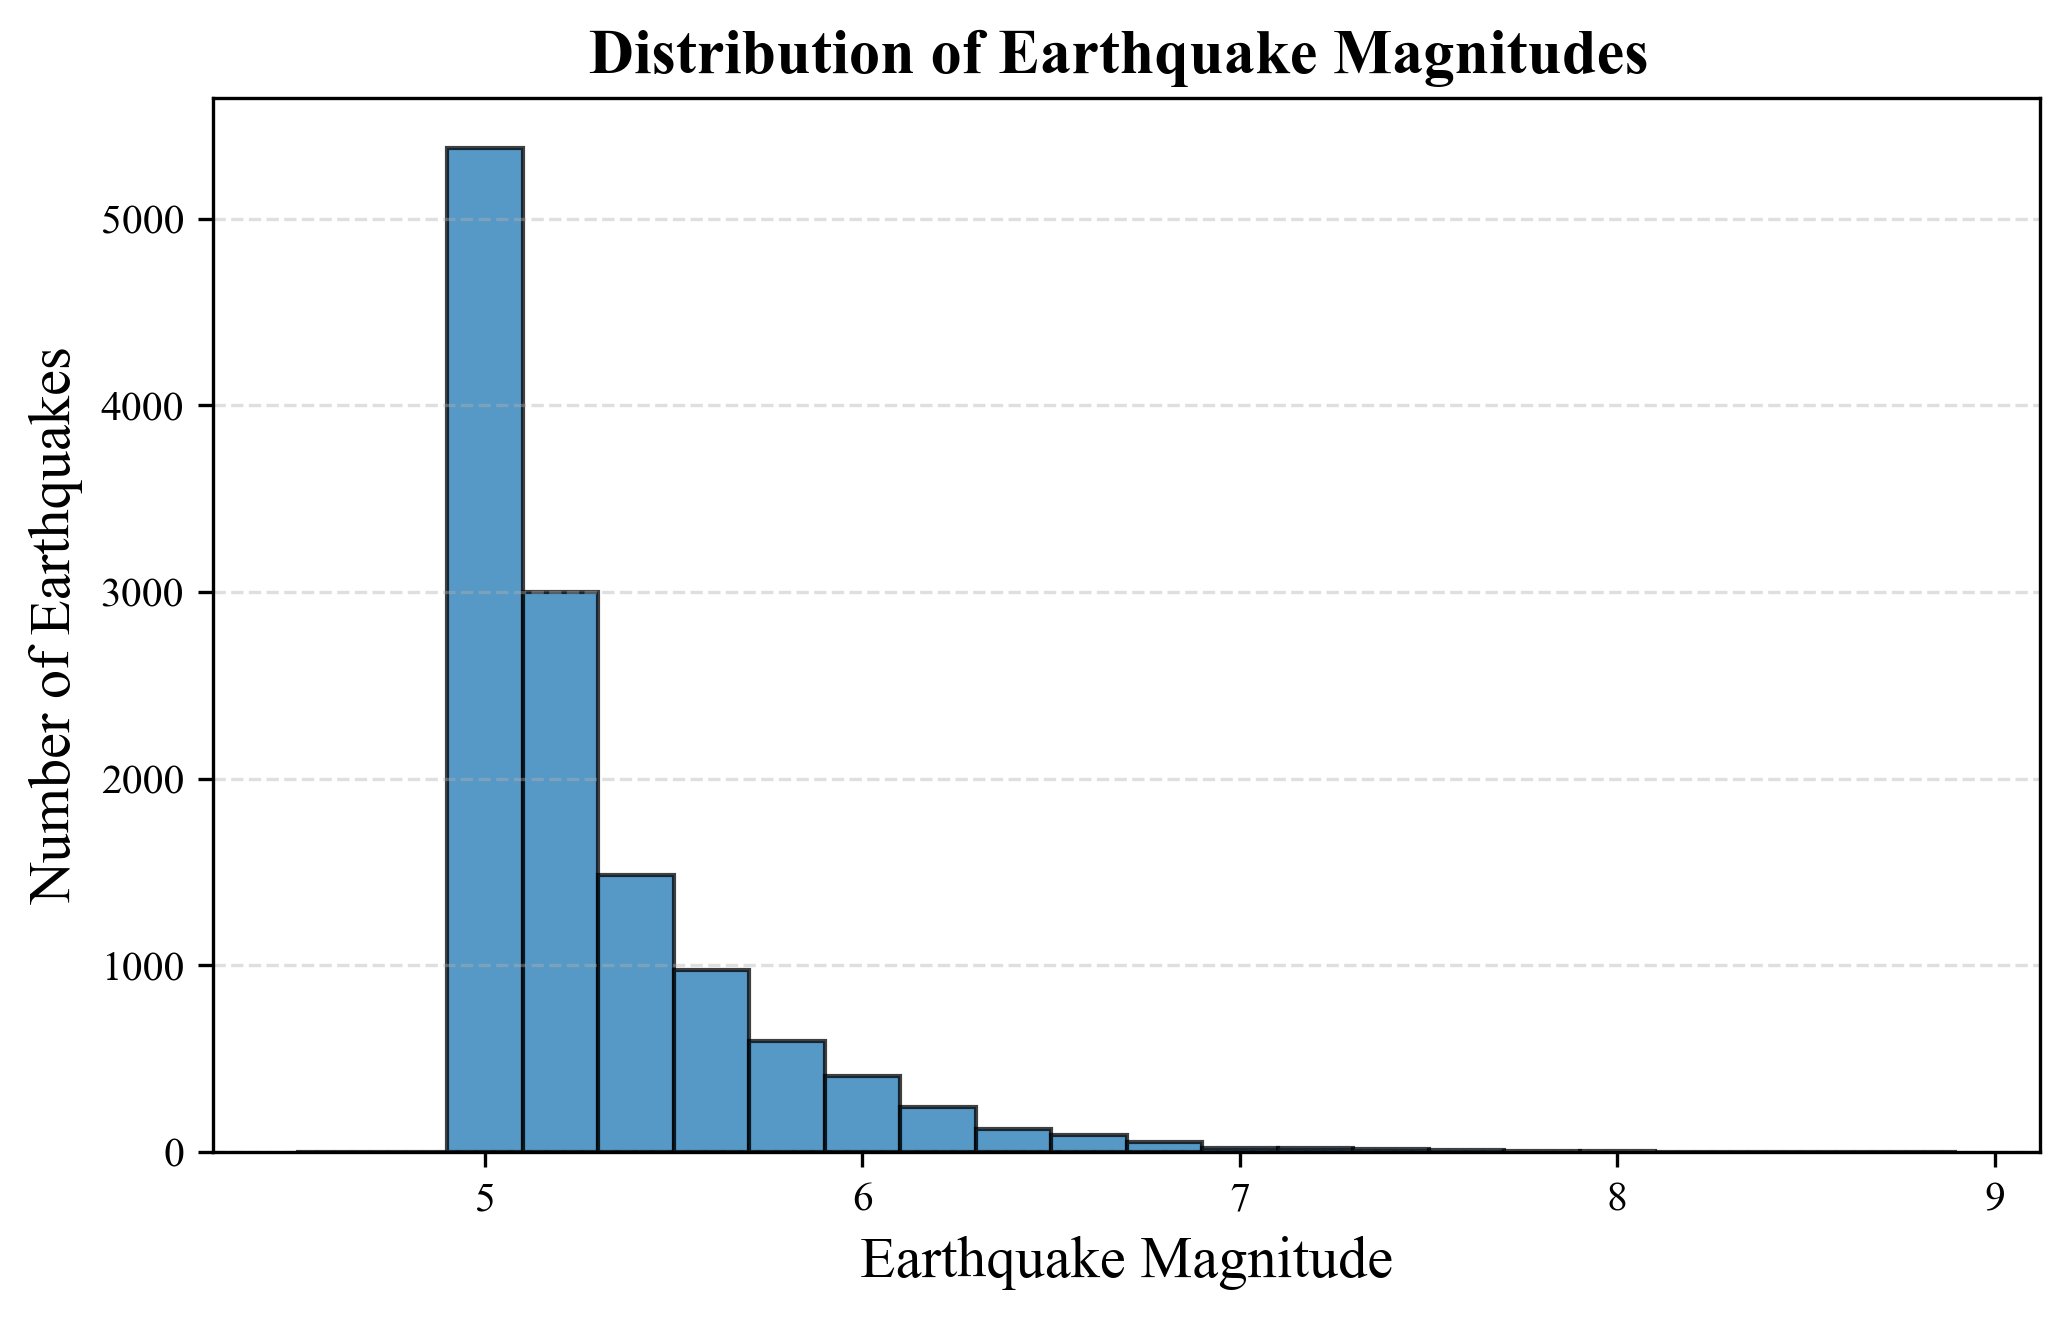

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select earthquakes with magnitude >= 6
df6 = eq.copy()
df6["mag"] = pd.to_numeric(df6["mag"], errors="coerce")
# df6 = df6[df6["mag"] >= 4.9].dropna(subset=["mag"])

# Plot magnitude distribution
plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(7, 4.5), dpi=300)

bins = np.arange(4.5, df6["mag"].max() + 0.2, 0.2)

plt.hist(
    df6["mag"],
    bins=bins,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("Earthquake Magnitude", fontsize=14)
plt.ylabel("Number of Earthquakes", fontsize=14)
plt.title("Distribution of Earthquake Magnitudes ", fontsize=15, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Average number of events per day: 5.0


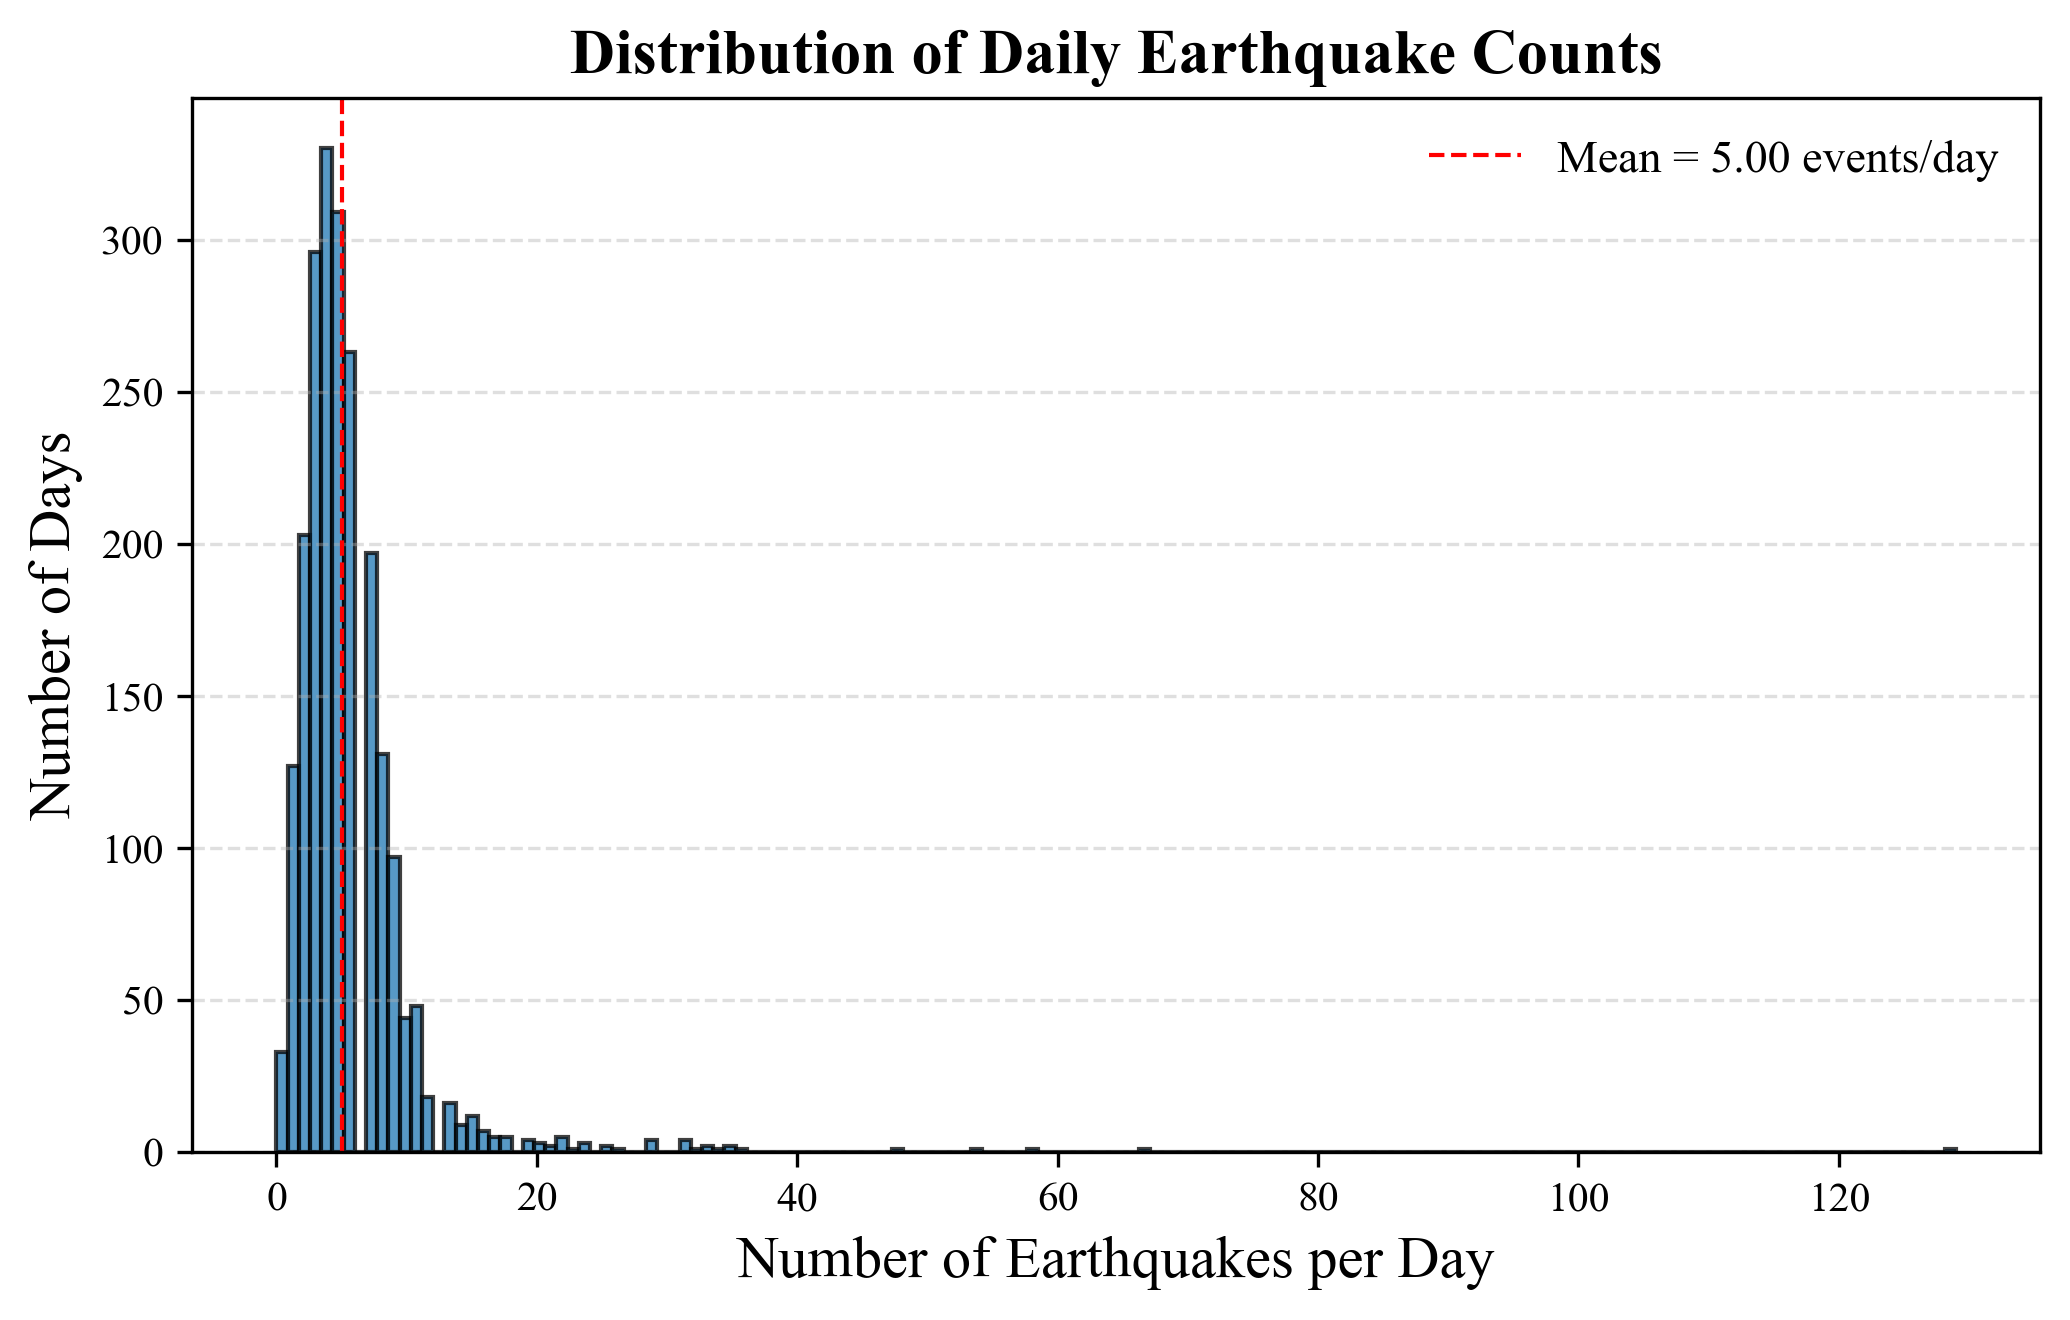

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure Time is datetime
eq["Time"] = pd.to_datetime(eq["Time"])

# Count number of earthquakes per day
daily_counts = eq.groupby(eq["Time"].dt.date).size()

# Include missing days as zero-event days
date_range = pd.date_range(eq["Time"].min().date(), eq["Time"].max().date(), freq="D")
daily_counts = daily_counts.reindex(date_range.date, fill_value=0)

# Average number of events per day
avg_events_per_day = np.median(daily_counts)

print("Average number of events per day:", avg_events_per_day)

# Plot distribution
plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(7, 4.5), dpi=300)

plt.hist(
    daily_counts,
    bins=150,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    avg_events_per_day,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Mean = {avg_events_per_day:.2f} events/day"
)

plt.xlabel("Number of Earthquakes per Day", fontsize=14)
plt.ylabel("Number of Days", fontsize=14)
plt.title("Distribution of Daily Earthquake Counts", fontsize=15, fontweight="bold")

plt.legend(frameon=False, fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Year
2005    5.052055
2006    5.150685
2007    6.260274
2008    5.368852
2009    5.679452
2010    6.561644
Name: Event_Count, dtype: float64


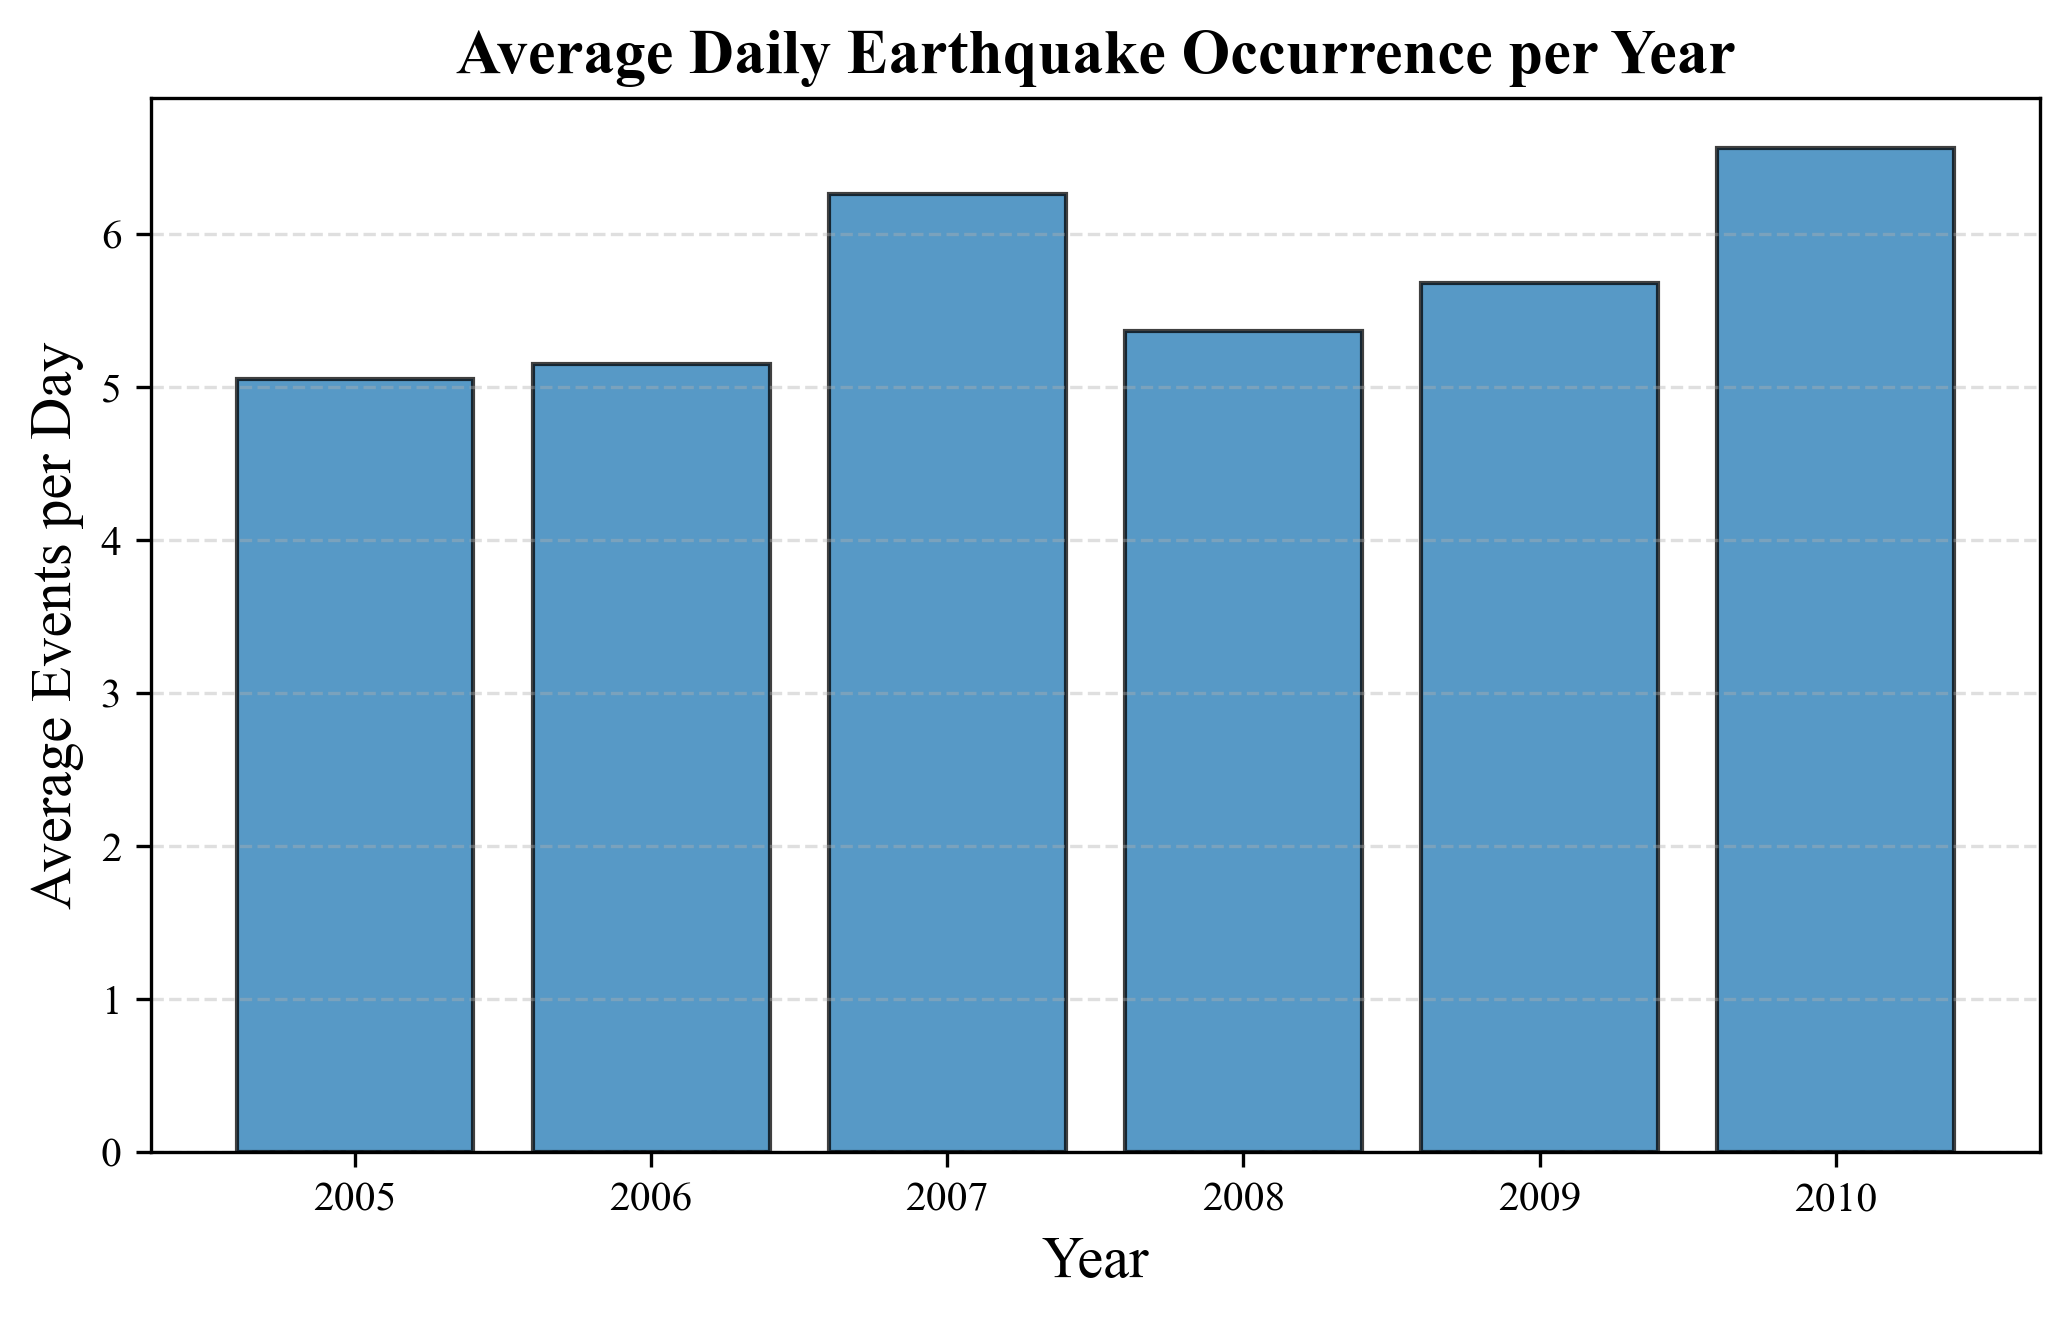

In [12]:
# Convert daily_counts to dataframe
daily_df = daily_counts.reset_index()
daily_df.columns = ["Date", "Event_Count"]
daily_df["Date"] = pd.to_datetime(daily_df["Date"])
daily_df["Year"] = daily_df["Date"].dt.year

# Average events per day per year
yearly_avg = daily_df.groupby("Year")["Event_Count"].mean()

print(yearly_avg)

# Plot yearly average
plt.figure(figsize=(7, 4.5), dpi=300)

plt.bar(
    yearly_avg.index.astype(str),
    yearly_avg.values,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Events per Day", fontsize=14)
plt.title("Average Daily Earthquake Occurrence per Year", fontsize=15, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()